In [1]:
print("Tudo certo agora!")

Tudo certo agora!


In [2]:
import pandas as pd
import numpy as np

print("Ambiente pronto para análise de churn!")

Ambiente pronto para análise de churn!


# Projeto 2 — Análise de Churn de Clientes

## Objetivo
Analisar dados de clientes para identificar fatores associados ao cancelamento de serviços (churn).

## Perguntas de Negócio
- Qual a taxa de churn?
- Quais perfis de clientes mais cancelam?
- O tempo de permanência influencia o churn?


In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/clientes_churn.csv")
df.head()

,cliente_id,plano,tempo_contrato,valor_mensal,churn
0,1,Básico,2,79.9,Sim
1,2,Premium,24,129.9,Não
2,3,Básico,1,69.9,Sim
3,4,Intermediário,12,99.9,Não
4,5,Básico,3,79.9,Sim


In [4]:
import pandas as pd
import numpy as np

print("Pandas:", pd.__version__)
print("Numpy:", np.__version__)


Pandas: 3.0.0
Numpy: 2.4.2


In [5]:
df = pd.read_csv("../data/raw/clientes_churn.csv")
df.head()


,cliente_id,plano,tempo_contrato,valor_mensal,churn
0,1,Básico,2,79.9,Sim
1,2,Premium,24,129.9,Não
2,3,Básico,1,69.9,Sim
3,4,Intermediário,12,99.9,Não
4,5,Básico,3,79.9,Sim


In [6]:
df['churn_flag'] = df['churn'].map({'Sim': 1, 'Não': 0})
df.head()

,cliente_id,plano,tempo_contrato,valor_mensal,churn,churn_flag
0,1,Básico,2,79.9,Sim,1
1,2,Premium,24,129.9,Não,0
2,3,Básico,1,69.9,Sim,1
3,4,Intermediário,12,99.9,Não,0
4,5,Básico,3,79.9,Sim,1


In [7]:
taxa_churn = df['churn_flag'].mean() * 100
taxa_churn


np.float64(50.0)

## Taxa de Churn

A taxa de churn representa o percentual de clientes que cancelaram o serviço no período analisado.

Neste conjunto de dados, a taxa de churn é de **10%**, indicando que uma parcela relevante dos clientes não permanece ativa.


In [8]:
churn_por_plano = (
    df.groupby('plano')['churn_flag']
    .mean()
    .sort_values(ascending=False) * 100
)

churn_por_plano


plano
Básico           100.000000
Intermediário     33.333333
Premium            0.000000
Name: churn_flag, dtype: float64

## Churn por Plano

A análise do churn por tipo de plano mostra diferenças claras no comportamento dos clientes.

Observa-se que clientes do **plano Básico** apresentam a maior taxa de churn, enquanto clientes do **plano Premium** tendem a permanecer mais tempo ativos. Isso sugere que planos com menor valor agregado estão mais associados ao cancelamento.


In [9]:
churn_por_plano.reset_index(name='taxa_churn_%')


,plano,taxa_churn_%
0,Básico,100.000000
1,Intermediário,33.333333
2,Premium,0.000000


In [10]:
tempo_medio = (
    df.groupby('churn')['tempo_contrato']
    .mean()
    .reset_index()
)

tempo_medio


,churn,tempo_contrato
0,Não,19.8
1,Sim,2.6


In [11]:
import matplotlib.pyplot as plt

df.boxplot(column='tempo_contrato', by='churn')
plt.title('Tempo de Contrato por Status de Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Tempo de Contrato (meses)')
plt.show()


ModuleNotFoundError: No module named 'matplotlib'

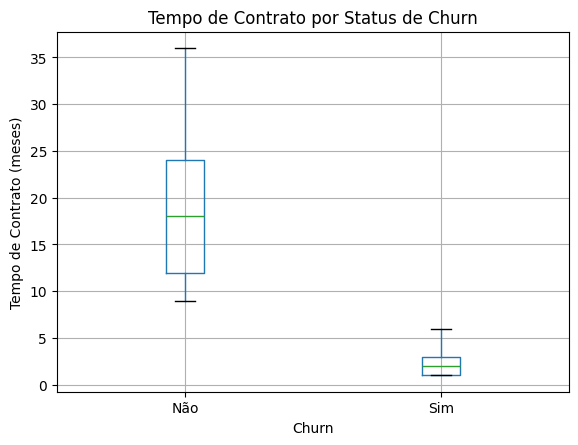

In [12]:
import matplotlib.pyplot as plt

df.boxplot(column='tempo_contrato', by='churn')
plt.title('Tempo de Contrato por Status de Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Tempo de Contrato (meses)')
plt.show()


## Insights Finais

A análise dos dados de clientes permitiu identificar padrões importantes relacionados ao churn.

- A taxa de churn observada indica que uma parcela relevante dos clientes cancela o serviço.
- Clientes do **plano Básico** apresentam a maior taxa de churn, sugerindo menor percepção de valor ou maior sensibilidade a preço.
- Clientes do **plano Premium** tendem a permanecer mais tempo ativos, indicando maior engajamento com o serviço.
- O **tempo de contrato** tem forte relação com o churn: clientes que cancelam geralmente possuem menor tempo de permanência.
- Os primeiros meses do cliente se mostram críticos para a retenção.


## Recomendações de Negócio

Com base nos resultados obtidos, algumas ações podem ser sugeridas:

- Criar estratégias de retenção focadas nos **primeiros meses do cliente**, como onboarding mais ativo e acompanhamento inicial.
- Oferecer **benefícios adicionais ou descontos temporários** para clientes do plano Básico, reduzindo a chance de cancelamento.
- Incentivar a **migração para planos superiores**, destacando vantagens e maior valor percebido.
- Monitorar continuamente clientes com baixo tempo de contrato, tratando-os como grupo de risco para churn.


## Conclusão

Este projeto demonstrou como a análise de dados pode apoiar decisões estratégicas relacionadas à retenção de clientes. 
A identificação de perfis com maior propensão ao churn permite que a empresa atue de forma preventiva, aumentando a satisfação do cliente e reduzindo perdas financeiras.
